# **Creating SMABackTester class from scratch**

In [3]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from itertools import product

In [4]:
class SMABackTester():      # Creating a class
  def __init__(self,company_symbol,start_date,end_date,SMA_S,SMA_L):
    self.company_symbol=company_symbol
    self.start_date=start_date
    self.end_date=end_date
    self.SMA_S=SMA_S
    self.SMA_L=SMA_L
    self.result={}
    self.get_data()
    self.calculate_data()

  # Method: get_data()
  def get_data(self):
    stock=yf.download(self.company_symbol,self.start_date,self.end_date)
    self.data=stock["Close"]

  # Method: calculate_date():
  def calculate_data(self):
    for symbol in self.company_symbol:
      df=pd.DataFrame(self.data[symbol]).copy()
      df.dropna(inplace=True)
      df["LR"]=np.log(df[symbol]/df[symbol].shift(1))
      df["SMA_S"]=df[symbol].rolling(window=self.SMA_S).mean()
      df["SMA_L"]=df[symbol].rolling(window=self.SMA_L).mean()
      df.dropna(inplace=True)
      self.result[symbol] = df

  # Method: set_parameters():Will be used for multiple combination of SMA_S & SMA_L
  def set_parameters(self,SMA_S=None,SMA_L=None):
    if self.SMA_S is not None:
      self.SMA_S=SMA_S
    if self.SMA_L is not None:
      self.SMA_L=SMA_L
    self.calculate_data()

  # Method: test_strategy(): will test the position and strategy for all SMA_S & SMA_L combination.
  def test_strategy(self):
    for symbol in self.company_symbol:
      df=pd.DataFrame(self.result[symbol]).copy()
      df["Signal"]=np.where(df["SMA_S"]>df["SMA_L"],1,-1)
      df["Strategy"]=df["Signal"].shift(1)*df["LR"]
      df.dropna(inplace=True)
      df["Cumulative Return"]=np.exp(df["LR"].cumsum())
      df["Cumulative Strategy"]=np.exp(df["Strategy"].cumsum())
      self.result[symbol]=df
    return self.result
  # Method: plot_result(): Will plot the results of the strategy for every ticker symbol
  def plot_result(self,ticker=None):
    if ticker is None:
      to_plot=self.company_symbol
    elif isinstance(ticker,str):
      to_plot=[ticker]
    else:
      to_plot=ticker
    for symbol in to_plot:
      if self.result[symbol] is None:
        print(f"Run the test_strategy() for {symbol} 1st!")
      else:
        df=self.result[symbol].copy()
        fig,(ax1,ax2)=plt.subplots(2,1,figsize=(12,10),sharex=True)
        ax1.plot(df.index, df[symbol], label="Price", alpha=0.5)
        ax1.plot(df.index, df["SMA_S"], label=f"SMA_S ({self.SMA_S})", color="orange")
        ax1.plot(df.index, df["SMA_L"], label=f"SMA_L ({self.SMA_L})", color="blue")
        ax1.set_title(f"{symbol} - SMA Crossover")
        ax1.set_ylabel("Price")
        ax1.legend()
        ax2.plot(df.index, df["Cumulative Strategy"], label="Strategy Performance", color="green")
        ax2.plot(df.index, df["Cumulative Return"], label="Buy & Hold", color="gray", linestyle="--")
        ax2.set_ylabel("Growth ($1 Invested)")
        ax2.legend()
        plt.show()

  # Method: optimixe_para(): make combination of SMA_S & SMA_L for different strategy output check
  def optimize_para(self,SMA_S_range,SMA_L_range):
    # making the combinations
    combination=list(product(range(*SMA_S_range),range(*SMA_L_range)))
    performance=[]
    for comb in combination:
      s,l=comb
      if s>l:
        continue
      self.set_parameters(s,l)
      # Access the result for the first company symbol and get the last 'Cumulative Strategy' value
      # Assuming optimization is based on the first company in the list
      df_first_company_result = self.test_strategy()[self.company_symbol[0]]
      performance.append(df_first_company_result["Cumulative Strategy"].iloc[-1])
    best_perf=np.max(performance)    # find best score
    opt=combination[np.argmax(performance)]    # find the SMA_S & SMA_L which gave the best score
    # Testing the best strategy by using optimal parameter (SMA_S & SMA_L)
    self.set_parameters(opt[0],opt[1])
    self.test_strategy()
    return self.performance

In [5]:
SMA_tester=SMABackTester(["BSE.NS","HAL.NS","FORTIS.NS","BTC-USD"],"2020-01-01","2026-01-07",7,20)
SMA_tester.test_strategy()

/tmp/ipython-input-463865429.py:14: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock=yf.download(self.company_symbol,self.start_date,self.end_date)
[*********************100%***********************]  4 of 4 completed


{'BSE.NS':                  BSE.NS        LR        SMA_S        SMA_L  Signal  Strategy  \
 Date                                                                            
 2020-01-29    54.659866  0.001478    54.489754    53.227395       1  0.001478   
 2020-01-30    53.983738 -0.012447    54.375865    53.290214       1 -0.012447   
 2020-01-31    53.827320 -0.002902    54.396047    53.388352       1 -0.002902   
 2020-02-03    52.838375 -0.018543    54.233865    53.525343       1 -0.018543   
 2020-02-04    53.408535  0.010733    53.990229    53.698914       1  0.010733   
 ...                 ...       ...          ...          ...     ...       ...   
 2025-12-31  2632.199951  0.019643  2667.771415  2689.474988      -1 -0.019643   
 2026-01-01  2628.000000 -0.001597  2646.699986  2683.319983      -1  0.001597   
 2026-01-02  2666.500000  0.014544  2636.557129  2678.394983      -1 -0.014544   
 2026-01-05  2673.899902  0.002771  2636.985700  2671.294983      -1 -0.002771   
 2026-

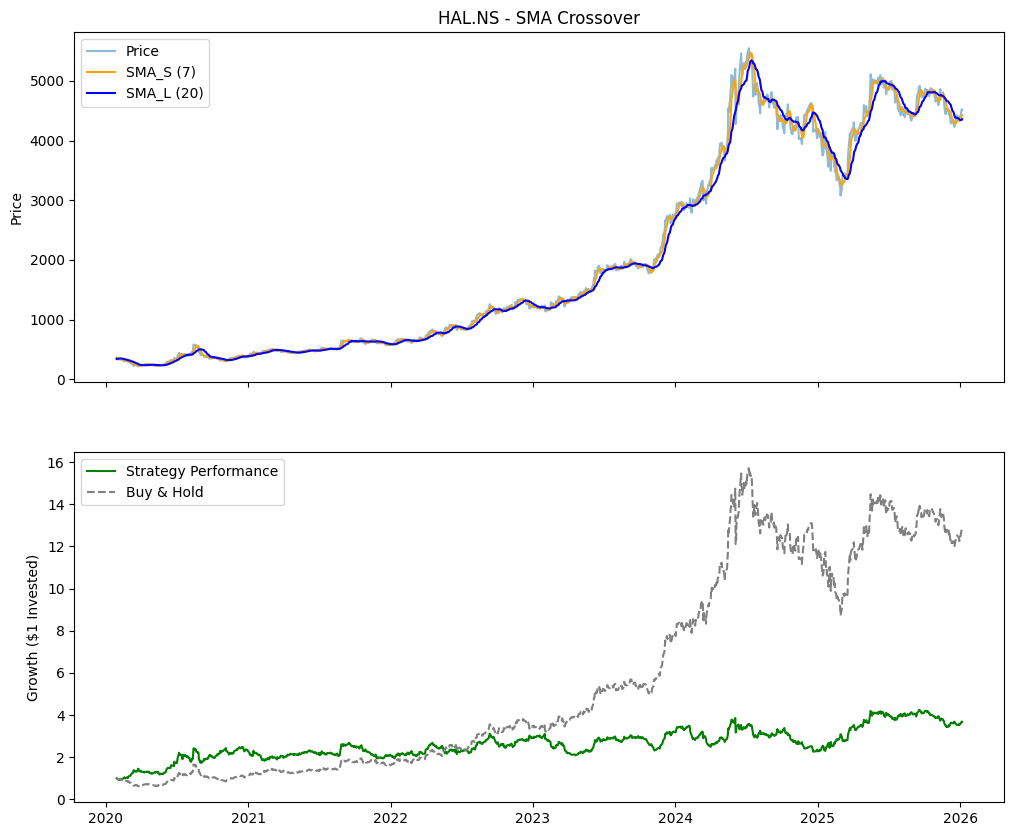

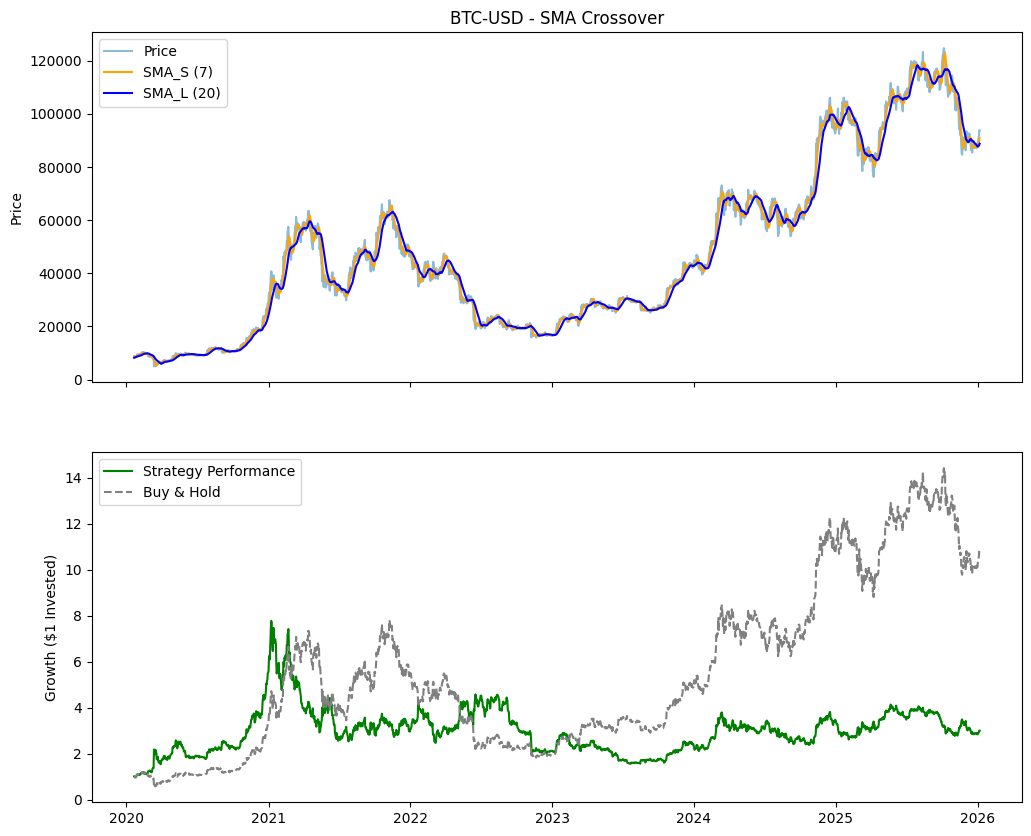

In [6]:
SMA_tester.plot_result(["HAL.NS","BTC-USD"])

In [8]:
SMA_tester.optimize_para((7,20,1),(20,100,1))

AttributeError: 'SMABackTester' object has no attribute 'performance'